# Part 1: Face & Eye Landmark Detection

Detect face and eye landmarks using [MediaPipe Face Landmarker](https://developers.google.com/mediapipe/solutions/vision/face_landmarker), with blink detection via blendshape scores.

In [ ]:
!pip install mediapipe
!wget -O face_landmarker_v2_with_blendshapes.task -q \
  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [ ]:
from google.colab import files

import cv2
from google.colab.patches import cv2_imshow
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np
import matplotlib.pyplot as plt
import math
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from PIL import Image, ImageDraw

In [ ]:
import glob
import re

img_list = glob.glob('./*.png')

def extract_number(item):
    match = re.search(r'\d+', item)
    return int(match.group()) if match else 0

sorted_list = sorted(img_list, key=extract_number)
sorted_list

['./face_1.png',
 './face_2.png',
 './face_3.png',
 './face_4.png',
 './face_5.png',
 './face_6.png',
 './face_7.png',
 './face_8.png',
 './face_9.png',
 './face_11.png',
 './face_12.png',
 './face_13.png',
 './face_14.png',
 './face_21.png',
 './face_22.png',
 './face_23.png',
 './face_24.png',
 './face_31.png',
 './face_32.png']

In [ ]:
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1
)
detector = vision.FaceLandmarker.create_from_options(options)

In [ ]:
def draw_landmarks_on_image(rgb_image, detection_result):
    face_landmarks_list = detection_result.face_landmarks
    annotated_image = np.copy(rgb_image)

    for i, l in enumerate(face_landmarks_list):
        face_landmarks = l
        face_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        face_landmarks_proto.landmark.extend([
            landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z)
            for landmark in face_landmarks
        ])

        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
                .get_default_face_mesh_tesselation_style()
        )
        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
                .get_default_face_mesh_contours_style()
        )
        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
                .get_default_face_mesh_iris_connections_style()
        )

    return annotated_image

In [ ]:
def make_landmark_image(img_name):
    img = mp.Image.create_from_file(img_name)
    detection_result = detector.detect(img)
    landmark_image = draw_landmarks_on_image(img.numpy_view()[..., :3], detection_result)

    blink_threshold = 0
    blink = 'eyes not found'
    if detection_result.face_blendshapes != []:
        for category in detection_result.face_blendshapes[0]:
            if 'Blink' in category.category_name:
                blink_threshold += category.score
        if blink_threshold > 1 / 2:
            blink = 'eyes closed'
        else:
            blink = 'eyes opened'

    return landmark_image, blink

### Landmark Detection Results

/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


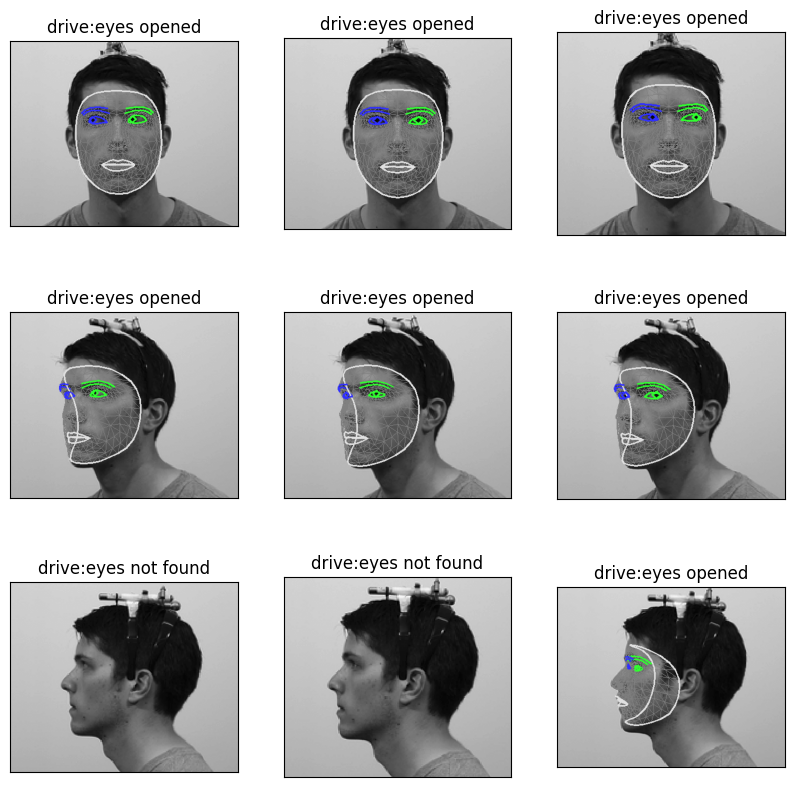

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        landmark_image, blink = make_landmark_image(sorted_list[3*i+j])
        axes[i, j].imshow(landmark_image)
        axes[i, j].set_title(sorted_list[3*i+j].split('/')[1].split('.')[0] + ':' + blink)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

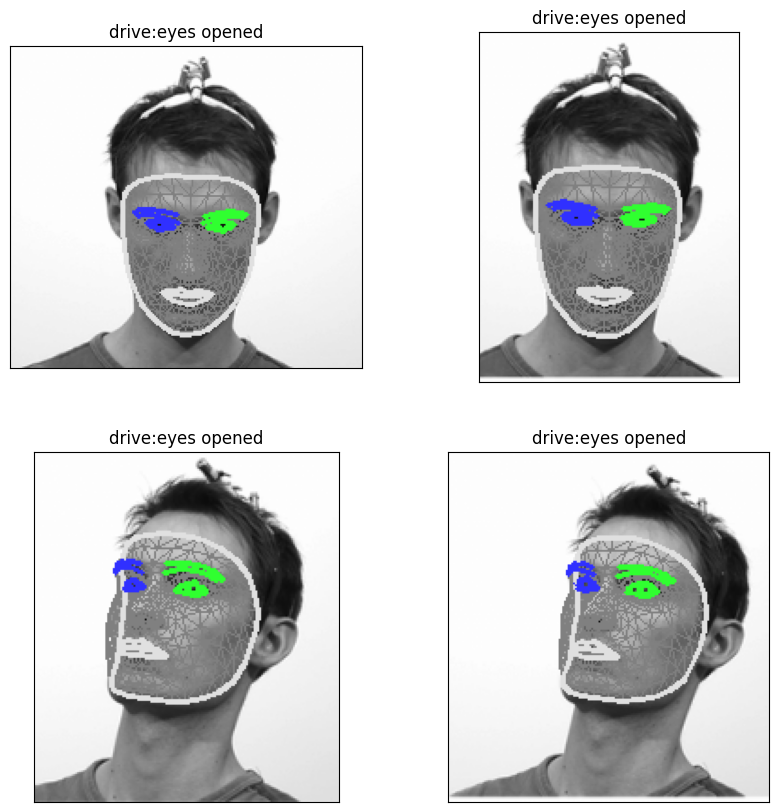

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    for j in range(2):
        landmark_image, blink = make_landmark_image(sorted_list[9+2*i+j])
        axes[i, j].imshow(landmark_image)
        axes[i, j].set_title(sorted_list[9+2*i+j].split('/')[1].split('.')[0] + ':' + blink)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

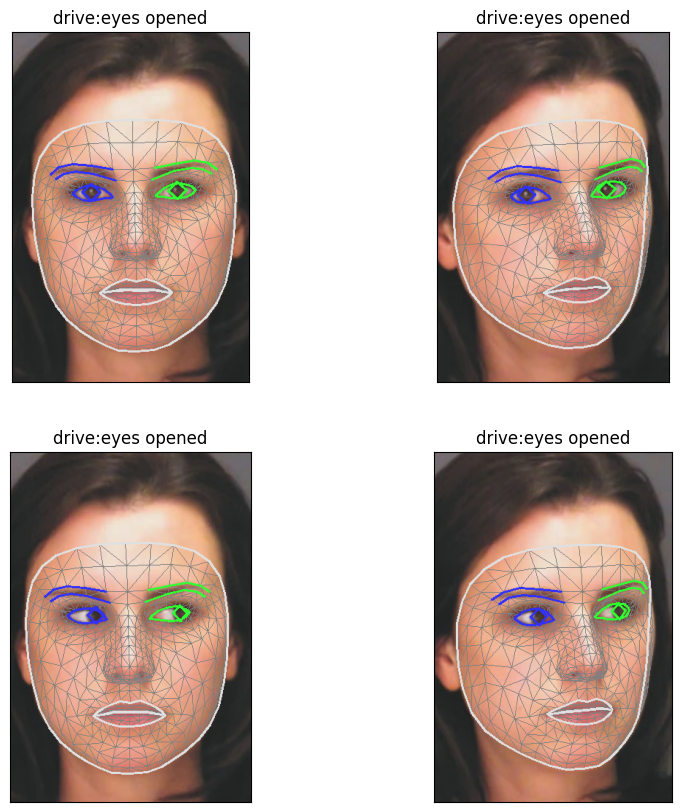

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    for j in range(2):
        landmark_image, blink = make_landmark_image(sorted_list[13+2*i+j])
        axes[i, j].imshow(landmark_image)
        axes[i, j].set_title(sorted_list[13+2*i+j].split('/')[1].split('.')[0] + ':' + blink)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

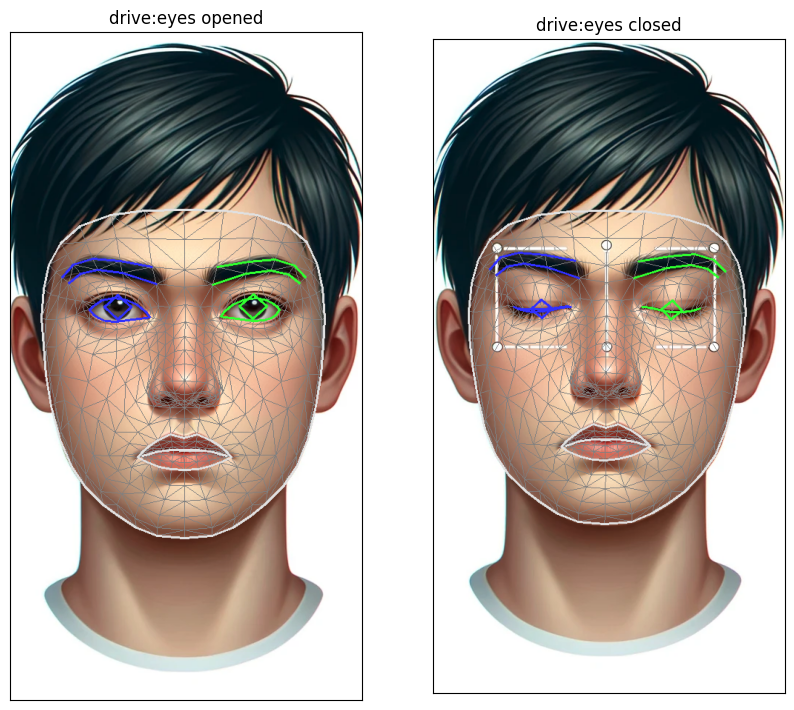

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
landmark_image, blink = make_landmark_image(sorted_list[17])
axes[0].imshow(landmark_image)
axes[0].set_title(sorted_list[17].split('/')[1].split('.')[0] + ':' + blink)
axes[0].set_xticks([])
axes[0].set_yticks([])

landmark_image, blink = make_landmark_image(sorted_list[18])
axes[1].imshow(landmark_image)
axes[1].set_title(sorted_list[18].split('/')[1].split('.')[0] + ':' + blink)
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.show()

### Discussion: Landmark Detection

- Even when only half the face is visible, MediaPipe can often detect landmarks from partial features like the jawline or eyes.
- The extracted landmarks are sufficient for downstream tasks.
- Blink detection via blendshape scores distinguishes open vs. closed eyes reliably.